--- Data Preview ---


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0



--- Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ticket_id         1500 non-null   object
 1   channel           1500 non-null   object
 2   customer_message  1500 non-null   object
 3   sentiment_label   1500 non-null   object
 4   word_count        1500 non-null   int64 
 5   urgent_flag       1500 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 70.4+ KB
None

--- Class Distribution ---
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


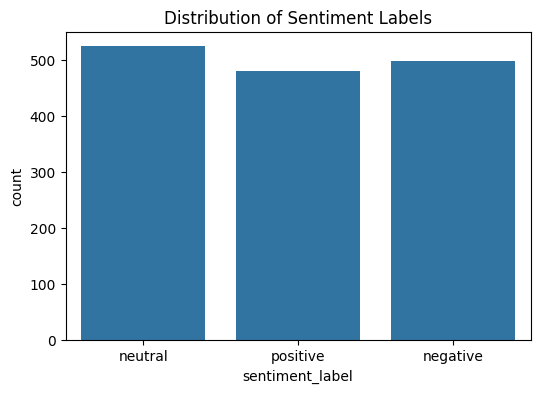


--- Text Length Analysis ---
Average word count: 12.72
Median word count: 12.0
Maximum word count: 26


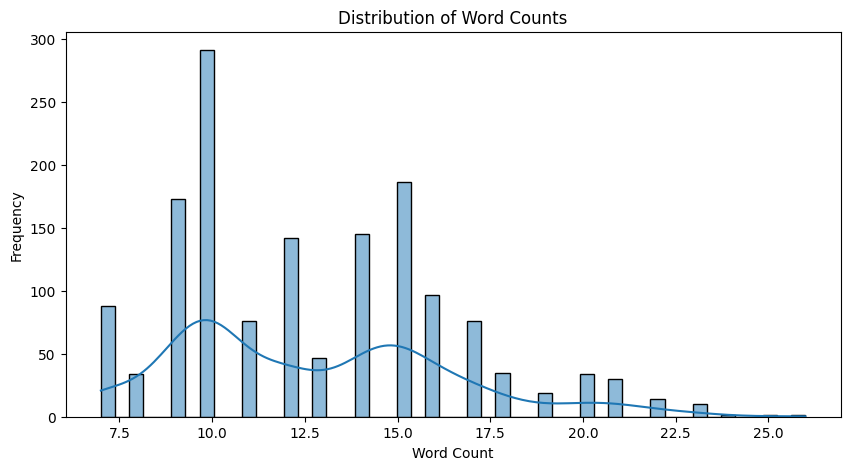

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile

# 1. Load the data
# Use the exact name from your sidebar!
zip_file_path = '/content/part_3_nlp_sequence_modeling-20260517T171127Z-3-001.zip'
csv_file_in_zip = 'part_3_nlp_sequence_modeling/customer_support_text_classification.csv'

with zipfile.ZipFile(zip_file_path, 'r') as z:
    with z.open(csv_file_in_zip) as f:
        df = pd.read_csv(f)

# 2. Peek at the first 5 rows
print("--- Data Preview ---")
display(df.head())

# 3. Check for missing values and column types
print("\n--- Dataset Summary ---")
print(df.info())

# 4. Check for Class Balance (Important for AI bias)
print("\n--- Class Distribution ---")
print(df['sentiment_label'].value_counts()) # Corrected column name

# 5. Visualize the labels
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment_label') # Corrected column name
plt.title('Distribution of Sentiment Labels')
plt.show()

# 6. Analyze Length (Word Count)
print("\n--- Text Length Analysis ---")
df['word_count'] = df['customer_message'].apply(lambda x: len(str(x).split())) # Apply to customer_message
print(f"Average word count: {df['word_count'].mean():.2f}")
print(f"Median word count: {df['word_count'].median()}")
print(f"Maximum word count: {df['word_count'].max()}")

plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Distribution of Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

In [6]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Clean the text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['clean_text'] = df['customer_message'].apply(clean_text)

# Convert labels to numbers (0: negative, 1: neutral, 2: positive)
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label_num'] = df['sentiment_label'].map(label_map)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=2000)
X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['label_num']
print("Text cleaned and vectorized successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Text cleaned and vectorized successfully!


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)

print("--- Baseline Model Results ---")
print(classification_report(y_test, baseline.predict(X_test)))

--- Baseline Model Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       104
           2       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Tokenize and Pad (Making all sentences length 50)
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])
X_seq = pad_sequences(sequences, maxlen=50)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_seq, y, test_size=0.2, random_state=42)

# Build the LSTM
model = Sequential([
    Embedding(5000, 64, input_length=50),
    LSTM(32),
    Dense(3, activation='softmax') # 3 Outputs for Neg, Neu, Pos
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("--- Training LSTM Model ---")
model.fit(X_train_seq, y_train_seq, epochs=5, batch_size=32, validation_split=0.1)

--- Training LSTM Model ---
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.6519 - loss: 0.9749 - val_accuracy: 0.8250 - val_loss: 0.7022
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9917 - loss: 0.3663 - val_accuracy: 1.0000 - val_loss: 0.1005
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 1.0000 - loss: 0.0449 - val_accuracy: 1.0000 - val_loss: 0.0171
Epoch 4/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 1.0000 - loss: 0.0122 - val_accuracy: 1.0000 - val_loss: 0.0090
Epoch 5/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 0.0054


### Task 6: Attention and Transformer Reflection

* **Why RNNs struggle:** Traditional RNNs process text one word at a time, which leads to the "Vanishing Gradient" problem. They tend to "forget" the beginning of long sentences.
* **The LSTM Upgrade:** LSTMs fix this by using a "Cell State" (like a memory stick) and gates to decide which words to keep and which to throw away.
* **The Power of Attention:** The Attention mechanism doesn't read word-by-word. It looks at the *entire* sentence at once and assigns mathematical weight to the most important words, regardless of where they are placed.
* **Transformers:** By using "Self-Attention," models like Transformers can process language in parallel, making them incredibly fast and the foundational architecture behind modern GenAI tools.

In [9]:
import numpy as np
import pandas as pd

# 1. Save Model Evaluation as CSV
loss, accuracy = model.evaluate(X_test_seq, y_test_seq, verbose=0)
eval_df = pd.DataFrame({'Metric': ['Loss', 'Accuracy'], 'Value': [loss, accuracy]})
eval_df.to_csv('model_evaluation.csv', index=False)

# 2. Save Sample Predictions as TXT
predictions = model.predict(X_test_seq[:5])
predicted_classes = np.argmax(predictions, axis=1)

with open('sample_predictions.txt', 'w') as f:
    f.write("--- Sample Predictions ---\n")
    for i in range(5):
        f.write(f"True Label (0=Neg, 1=Neu, 2=Pos): {y_test_seq.iloc[i]} | Predicted: {predicted_classes[i]}\n")

print("Files generated! Look in your Colab sidebar to download them.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 727ms/step
Files generated! Look in your Colab sidebar to download them.
